In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp


from neurodiffeq.conditions import IVP
from neurodiffeq import diff
from neurodiffeq.generators import Generator1D
from neurodiffeq.solvers import Solver1D, Solution1D, BundleSolution1D
from neurodiffeq.networks import FCNN
from neurodiffeq.conditions import BundleIVP 
import torch
import os
from delta_solver_mg_2 import DeltaSolver
from utils_2 import CustomCondition, f_R_reparams, _shape_manager
import yaml
import joblib
import torch.nn as nn

from scipy.stats import qmc
from neurodiffeq.solvers import BundleSolver1D
from neurodiffeq.generators import PredefinedGenerator

from scipy.constants import c as c_ms

from utils import CustomCondition, HS_reparams

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


b = 0.1

Om = 0.1; 0m = 0.3, Om = 0.4

k = 0.2, k = 0.6

In [67]:
H_0 = 70.0
h = H_0 / 100.0
Om_r_0 = 5.38*10**(-5)
Om_m_0 = 0.15
Om_L_0 = 1.0 - Om_m_0 - Om_r_0
c_ms = 299792458.0
c = c_ms / 1000.0

b = 0.1
k_val = 0.006
#k_val = k_val1 * h
Lambda = 3 * (H_0 ** 2) * (1 - Om_m_0) / c**2

# Parámetros de integración
z_0 = 20.0
z_f = 0.0
b_max = 5.0
a_0 = 1/31.0
a_f = 1.0
N_0 = np.log(a_0)
N_f = np.log(a_f)
n_0 = abs(N_0)

N_p_0 = N_0 / n_0
N_p_f = N_f / n_0

# -----------------------------------------------------------------------------
# 3. DEFINICIÓN DE LA RED (Igual a la tuya)
# -----------------------------------------------------------------------------
class RegressionNN(nn.Module):
    """ Neural network for regression with 4 input features and 2 output targets. """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        
    def forward(self, x):
        return self.network(x)

# -----------------------------------------------------------------------------
# 4. CARGA DEL MODELO Y SCALERS
# -----------------------------------------------------------------------------
folder_path = '/home/javier-pineau/Escritorio/Tesis/red-pedro'
network_name = '_para_javi'

path_model = os.path.join(folder_path, f'regression_model{network_name}.pth')
path_scaler_X = os.path.join(folder_path, f'scaler_X{network_name}.pkl')
path_scaler_y = os.path.join(folder_path, f'scaler_y{network_name}.pkl')

print(f"Cargando red neuronal desde: {path_model}")

# Cargar modelo directamente al DEVICE correcto
model_pedro = RegressionNN()
# map_location asegura que se cargue en GPU si está disponible
model_pedro.load_state_dict(torch.load(path_model, map_location=device))
model_pedro.to(device) # Aseguramos que esté en GPU
model_pedro = model_pedro.double()  # Convertir modelo a double para compatibilidad con neurodiffeq
model_pedro.eval()

# Cargar scalers (estos siempre trabajan en CPU con numpy)
scaler_X = joblib.load(path_scaler_X)
scaler_y = joblib.load(path_scaler_y)

# -----------------------------------------------------------------------------
# 5. PREDICCIÓN (CORRECCIÓN DE TIPOS)
# -----------------------------------------------------------------------------
# Features: ["a", "k h", "h", "Omega_m"]
kh_input = k_val / h 

# Input array (Numpy crea float64 por defecto)
X_input = np.array([[a_0, kh_input, h, Om_m_0]])

# Escalar (en CPU)
X_scaled = scaler_X.transform(X_input)
# Convertir a float64 para compatibilidad con neurodiffeq y el modelo en double
X_tensor = torch.tensor(X_scaled, dtype=torch.float64).to(device)

print("Realizando predicción...")

# Predecir
with torch.no_grad():
    y_pred_scaled = model_pedro(X_tensor)

# Volver a CPU para usar el scaler inverso
y_pred = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy())

# Extraer resultados
delta_pred_pedro = y_pred[0, 0]
delta_prime_pred_pedro = y_pred[0, 1]

print("\n--- Resultados de la Red Neuronal de Pedro ---")
print(f"Parámetros usados: a={a_0:.4f}, k/h={kh_input:.4f}, h={h:.4f}, Om_m={Om_m_0:.4f}")
print(f"Predicción Delta:       {delta_pred_pedro}")
print(f"Predicción Delta Prime: {delta_prime_pred_pedro}")

# -----------------------------------------------------------------------------
# 6. CONDICIONES INICIALES PARA EL SOLVER
# -----------------------------------------------------------------------------
delta_inicial = delta_pred_pedro
delta_p_inicial = delta_prime_pred_pedro

# Cambio de variables (Ojo con el logaritmo de un número negativo si delta < 0)
delta_inicial_net = np.log(np.abs(delta_inicial))
delta_p_inicial_net = n_0 * a_0 * (delta_p_inicial / delta_inicial)

print(f"\nNuevas condiciones iniciales aplicadas al solver:")
print(f"delta_inicial_net (log): {delta_inicial_net}")
print(f"delta_p_inicial_net:     {delta_p_inicial_net}")

Cargando red neuronal desde: /home/javier-pineau/Escritorio/Tesis/red-pedro/regression_model_para_javi.pth
Realizando predicción...

--- Resultados de la Red Neuronal de Pedro ---
Parámetros usados: a=0.0323, k/h=0.0086, h=0.7000, Om_m=0.1500
Predicción Delta:       -87.27874735462842
Predicción Delta Prime: -2675.7483941146347

Nuevas condiciones iniciales aplicadas al solver:
delta_inicial_net (log): 4.46910698938961
delta_p_inicial_net:     3.396047434710482


/home/javier-pineau/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [68]:
model = 'Hu-Sawicki'
path = f'/home/javier-pineau/Escritorio/Tesis/Códigos Augusto/f_R_nets_for_multiuse/{model}_nets'

with open(f'{path}/saved_config.yaml') as yaml_file_f_R:
    try:
        Config_f_R = yaml.safe_load(yaml_file_f_R)
    except yaml.YAMLError as exc:
        print(exc)

# Set the range of the independent variable:
z_rescale = z_0 

z_prime_min = 0.0
z_prime_max = 1.0
z_min = z_prime_min
z_max = z_rescale * z_prime_max

# Set the range of the parameters of the bundle:
b_prime_min = float(Config_f_R['b_prime_min'])
b_prime_max = 1.0
b_max = Config_f_R['b_max']
b_min = b_prime_min * b_max

Om_m_0_min = Config_f_R['Om_m_0_min']
Om_m_0_max = Config_f_R['Om_m_0_max']

# Set neural network parameters and renormalizations:
alpha_nominator = Config_f_R['alpha_nominator']
alpha_denominator = Config_f_R['alpha_denominator']
alpha = alpha_nominator / alpha_denominator

# --- CORRECCIÓN AQUÍ: Cargar al 'device' (GPU), no a CPU ---
fR_nets = torch.load(f'{path}/nets_f_R.ph', map_location=device, weights_only=False)

f_R = f_R_reparams(z_0=z_0, b_prime_min=b_prime_min, b_max=b_max, alpha=alpha)

conditions = [
    CustomCondition(f_R.v_reparam),
    CustomCondition(f_R.r_prime_reparam)
]

r_prime_net_index = -1
v_net_index = 2

for i, net in enumerate(fR_nets):
    try:
        fR_nets[i] = net.to(device)
    except Exception:
        pass

r_prime = BundleSolution1D([fR_nets[r_prime_net_index]], [conditions[-1]])
v = BundleSolution1D([fR_nets[v_net_index]], [conditions[0]])

def H(z, theta, **kwargs):
    """Función que calcula el parámetro de Hubble H(z)"""
    b, Om_m_0, H_0 = theta  
    
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        # Asegurate que _shape_manager esté definido
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        # Om_m_0 original sigue siendo un float/array de numpy
        Om_m_0_np = Om_m_0 * shape 

    # --- CORRECCIÓN --- 
    # Creamos tensores con nombres nuevos (agregando _t) para NO pisar las variables de numpy
    z_prime_t = torch.tensor(z_prime, device=device, dtype=torch.float64)
    b_prime_t = torch.tensor(b_prime, device=device, dtype=torch.float64)
    Om_m_0_t  = torch.tensor(Om_m_0_np, device=device, dtype=torch.float64)

    # Usamos los tensores para evaluar la red neuronal
    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)

    # Como usamos nombres distintos para los tensores, Om_m_0_np sigue estando en la CPU y en formato numpy.
    # Ahora la cuenta funciona perfecto sin crashear.
    out = H_0 * np.sqrt(((1 - Om_m_0_np) / 2) * np.exp(r_prime_sol) / v_sol)

    if no_reshape:
        out = out[0][0]
    return out
z_examples = np.linspace(0, z_0, 10000) 
theta_example = [b, Om_m_0, H_0]


H_values = H(z_examples, theta_example)
solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k_val)
solver_clase.z_ini_HS = z_0  

H_interp, Hprime_interp, r_interp = solver_clase.H_HS()

In [94]:
def Geff_G_func(z, k, b, Om_m_0, Lambda_val, debug=False, **kwargs):
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        Om_m_0 = Om_m_0 * shape

    # Convertir a tensores en el dispositivo correcto
    z_prime = torch.tensor(z_prime, device=device, dtype=torch.float64)
    b_prime = torch.tensor(b_prime, device=device, dtype=torch.float64)
    Om_m_0 = torch.tensor(Om_m_0, device=device, dtype=torch.float64)

    r_prime_sol = r_prime(z_prime, b_prime, Om_m_0, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime, b_prime, Om_m_0, to_numpy=True, no_reshape=no_reshape)

    r_prime_exp = np.exp(r_prime_sol)

    denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)  

    FR = 1.0 - 2.0 / (b * (denomFR ** 2))
    FRR = 4.0 / (Lambda_val * b**2 * (denomFR ** 3))


    m = FRR / FR
    epsilon = (k**2) * (1.0 + z)**2 * m

    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)

    return Geff_over_G





Geff_class = solver_clase.Geff(z_examples, r_interp)

Geff_nets = Geff_G_func(z_examples, k_val * h, b, Om_m_0, Lambda)  
Geff_interp_from_nets = interp1d(z_examples, Geff_nets, kind='cubic', fill_value="extrapolate")    

H_interp_class, Hprime_interp_class, r_interp_class = solver_clase.H_HS()
z_range_class = np.linspace(0, solver_clase.z_ini_HS, 1000)
H_class = H_interp_class(z_range_class) * H_0  
r_class = r_interp_class(z_range_class)

shape = np.ones_like(z_range_class)
z_prime = 1 - (z_range_class / z_0)
b_prime = (b / b_max) * shape
Om_m_0_prime = Om_m_0 * shape

#r_prime_sol = r_prime(z_prime, b_prime, Om_m_0_prime, to_numpy=True)
#r_redes_values = np.exp(r_prime_sol)

z_vec_class, x_vec_class, v_vec_class, r_vec_class = solver_clase.integ_HS()

v_interp_class = interp1d(z_vec_class, v_vec_class, bounds_error=False, fill_value="extrapolate")
v_class = v_interp_class(z_range_class)

x_interp_class = interp1d(z_vec_class, x_vec_class, bounds_error=False, fill_value="extrapolate")
x_clase = x_interp_class(z_range_class)

#v_redes_values = v(z_prime, b_prime, Om_m_0_prime, to_numpy=True)

In [70]:
H_interp_class, Hprime_interp_class, r_interp_class = solver_clase.H_HS()
z_range_class = np.linspace(0, solver_clase.z_ini_HS, 1000)
H_class = H_interp_class(z_range_class) * H_0  
r_class = r_interp_class(z_range_class)

shape = np.ones_like(z_range_class)
z_prime = 1 - (z_range_class / z_0)
b_prime = (b / b_max) * shape
Om_m_0_prime = Om_m_0 * shape

# Convertir a tensores en el dispositivo correcto
z_prime = torch.tensor(z_prime, device=device, dtype=torch.float64)
b_prime = torch.tensor(b_prime, device=device, dtype=torch.float64)
Om_m_0_prime = torch.tensor(Om_m_0_prime, device=device, dtype=torch.float64)

r_prime_sol = r_prime(z_prime, b_prime, Om_m_0_prime, to_numpy=True)
r_redes_values = np.exp(r_prime_sol)

z_vec_class, x_vec_class, v_vec_class, r_vec_class = solver_clase.integ_HS()

v_interp_class = interp1d(z_vec_class, v_vec_class, bounds_error=False, fill_value="extrapolate")
v_class = v_interp_class(z_range_class)

x_interp_class = interp1d(z_vec_class, x_vec_class, bounds_error=False, fill_value="extrapolate")
x_clase = x_interp_class(z_range_class)

v_redes_values = v(z_prime, b_prime, Om_m_0_prime, to_numpy=True)

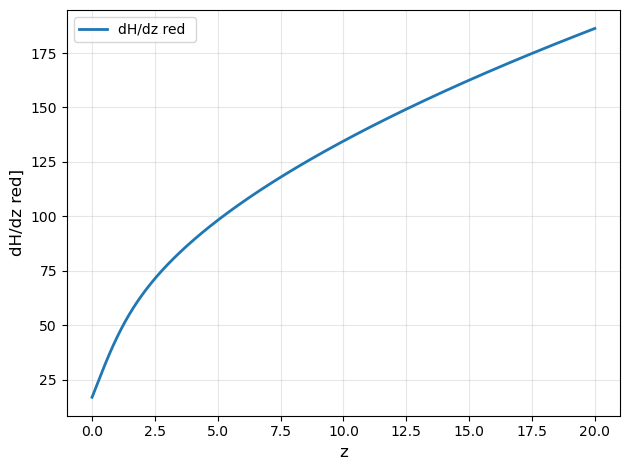

In [71]:
x_net_index = 0
x_condition = CustomCondition(f_R.x_reparam)
x = BundleSolution1D([fR_nets[x_net_index]], [x_condition])

def dH_dz_red(z, theta):
    global device
    b, Om_m_0, H_0_local = theta

    z = np.asarray(z)
    z_prime = 1 - (z / z_rescale)
    b_prime = np.full_like(z, b / b_max)
    Om_m_0_arr = np.full_like(z, Om_m_0)

    # Convertir a tensores en el dispositivo correcto
    z_prime = torch.tensor(z_prime, device=device, dtype=torch.float64)
    b_prime = torch.tensor(b_prime, device=device, dtype=torch.float64)
    Om_m_0_arr = torch.tensor(Om_m_0_arr, device=device, dtype=torch.float64)

    r_prime_sol = r_prime(z_prime, b_prime, Om_m_0_arr, to_numpy=False)
    v_sol = v(z_prime, b_prime, Om_m_0_arr, to_numpy=False)
    x_sol = x(z_prime, b_prime, Om_m_0_arr, to_numpy=False)

    dtype = r_prime_sol.dtype
    device = r_prime_sol.device

    r = torch.exp(r_prime_sol)
    b_tensor = torch.as_tensor(b_prime * b_max, dtype=dtype, device=device)
    Om_m_0_t = torch.as_tensor(Om_m_0_arr, dtype=dtype, device=device)
    z_t = torch.as_tensor(z, dtype=dtype, device=device)

    Gamma = (r + b_tensor) * (((r + b_tensor) ** 2) - 2.0 * b_tensor) / (4.0 * b_tensor * r)
    denom = z_t + 1.0

    dr_dz = - r * Gamma * x_sol / denom
    dv_dz = - v_sol * (x_sol * Gamma + 4.0 - 2.0 * v_sol) / denom

    coef1 = 0.25 * (1.0 - Om_m_0_t)
    coef2 = torch.sqrt(r / (2.0 * v_sol) * (1.0 - Om_m_0_t))


    dH = coef1 / coef2 * (dr_dz / v_sol - r * dv_dz / (v_sol ** 2))
    return dH.detach().cpu().numpy()


theta_example = [b, Om_m_0, H_0]

dH_net_values =H_0* dH_dz_red(z_examples, theta_example)


plt.plot(z_examples, dH_net_values, label='dH/dz red ', linewidth=2)
plt.xlabel('z', fontsize=12)
plt.ylabel('dH/dz red]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

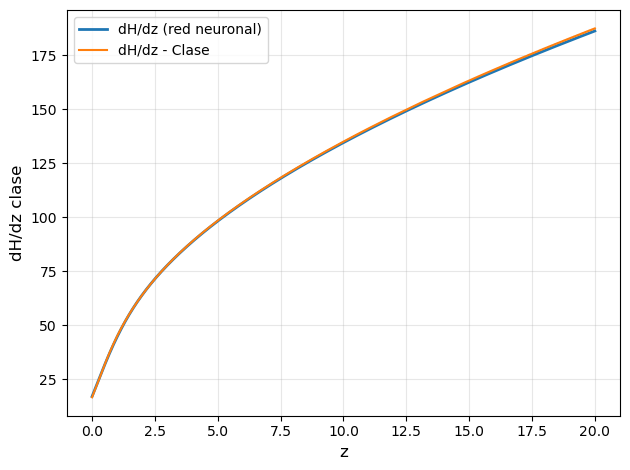

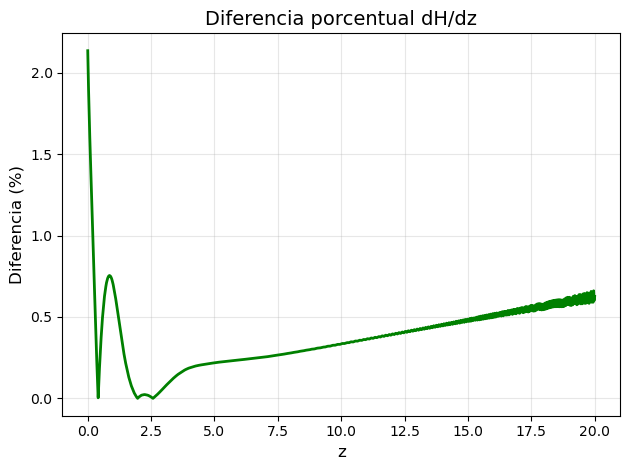

In [72]:
dH_dz_clase_values =H_0* solver_clase.dH_dz(z=z_range_class, r=r_class, v=v_class, x=x_clase)


plt.plot(z_examples, dH_net_values, label='dH/dz (red neuronal)', linewidth=2)
plt.plot(z_range_class, dH_dz_clase_values, label='dH/dz - Clase')
plt.legend(fontsize=10)
plt.xlabel('z', fontsize=12)
plt.ylabel('dH/dz clase', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dH_interp_class_to_examples = interp1d(z_range_class, dH_dz_clase_values, bounds_error=False, fill_value="extrapolate")

dH_dz_clase = dH_interp_class_to_examples(z_examples)


dif_dH_dz = 100 * np.abs((dH_dz_clase - dH_net_values) / dH_dz_clase)

plt.plot(z_examples, dif_dH_dz, 'g-', linewidth=2)
plt.xlabel('z', fontsize=12)
plt.ylabel('Diferencia (%)', fontsize=12)
plt.title('Diferencia porcentual dH/dz', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


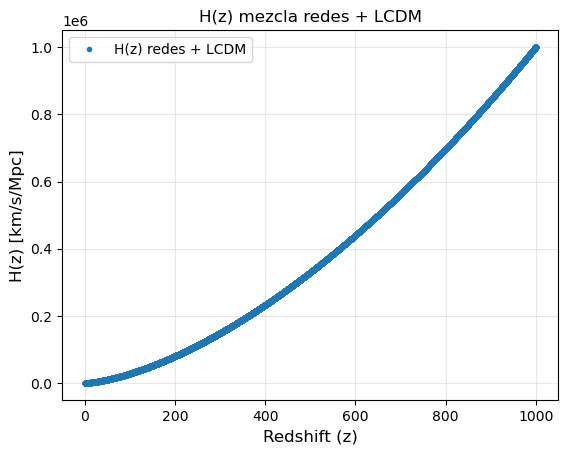

/tmp/ipykernel_12950/687178219.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


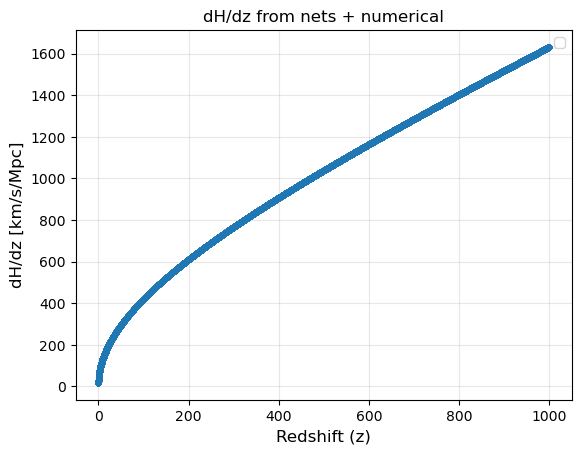

In [73]:
# Derivadas de red + expresión analítica de LCDM pegadas

def H_LCDM(a):
    inside = Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4)
    return H_0 * np.sqrt(inside)

def dH_da_LCDM(a):
    numerator = -3.0 * Om_m_0 * (a ** (-4)) - 4 * Om_r_0 * (a ** (-5))
    raiz = np.sqrt(Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4))
    dHda_ana = H_0 * numerator / (2 * raiz)
    return dHda_ana


z_lcdm = np.linspace(z_0, 1000, 100000)

dH_net_values =H_0* dH_dz_red(z_examples, theta_example)
da_dz = -1.0 / (1.0 + z_lcdm)**2

#LCDM

H_LCDM_segment = H_LCDM(1.0 / (1.0 + z_lcdm)) 
dH_dz_tramo_LCDM = dH_da_LCDM(1.0 / (1.0 + z_lcdm))*da_dz

#MG

H_MG_segment = H_values 
dH_dz_tramo_MG = dH_net_values 


z_comb = np.concatenate((z_examples, z_lcdm[1:]))
H_comb = np.concatenate((H_MG_segment, H_LCDM_segment[1:]))
dH_dz_comb = np.concatenate((dH_dz_tramo_MG, dH_dz_tramo_LCDM[1:]))

order = np.argsort(z_comb)
z_total = z_comb[order]
H_total = H_comb[order]
dH_dz_total = dH_dz_comb[order]

#sacar lo de abajo y ver qué pasa

mask = np.ones_like(z_total, dtype=bool)
z_clean = z_total #[mask]
H_clean = H_total#[mask]
dH_dz_clean = dH_dz_total#[mask]


plt.plot(z_total, H_total, '.', label='H(z) redes + LCDM')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('H(z) [km/s/Mpc]', fontsize=12)
#plt.xlim(19.8, 20.2)
#plt.ylim(5200, 5400)
plt.title('H(z) mezcla redes + LCDM')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.show()



plt.plot(z_total, dH_dz_total, '.')# label='dH/dz mezcla redes + LCDM')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('dH/dz [km/s/Mpc]', fontsize=12)

#plt.xlim(19.95, 20.1)

#plt.ylim(378,382)
plt.title('dH/dz from nets + numerical')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.show()
# construir malla limpia (borramos índices problemáticos)

In [ ]:
def ODE_MG_NN(X, X_p, N_p, k_param, Om_m_0, b, H_0, Lambda):
    N = N_p * n_0
    a = torch.exp(N)
    a_flat = a.view(-1)
    a_np = a.detach().cpu().numpy().reshape(-1)
    z_np = (1.0 / a_np) - 1.0
    z_np = np.asarray(z_np, dtype=np.float64)

    mu_np = Geff_G_func(z_np, k_param, b, Om_m_0, Lambda)
    mu_np = np.nan_to_num(mu_np, nan=1.0, posinf=1.0, neginf=1.0)
    mu_np[z_np > z_0] = 1.0
    
    H_z = np.interp(z_np, z_total, H_total, left=H_total[0], right=H_total[-1])
    dHdz = np.interp(z_np, z_total, dH_dz_total, left=dH_dz_total[0], right=dH_dz_total[-1])
    dHda = dHdz * (-1.0 / (a_np ** 2))

    target_device = X_p.device if isinstance(X_p, torch.Tensor) else a.device
    target_dtype  = X_p.dtype   if isinstance(X_p, torch.Tensor) else a.dtype
    np_dt = np.float64 if target_dtype == torch.float64 else np.float32

    H_t = torch.from_numpy(H_z.astype(np_dt)).to(device=target_device, dtype=target_dtype)
    dH_t = torch.from_numpy(dHda.astype(np_dt)).to(device=target_device, dtype=target_dtype)
    mu_t = torch.from_numpy(mu_np.astype(np_dt)).to(device=target_device, dtype=target_dtype)

    denom = (H_t ** 2) * (a_flat ** 3)
    
    term1 = n_0 * ((dH_t / H_t) * a_flat + 2)
    pref = (3 * Om_m_0 * (n_0 ** 2) * (H_0 ** 2)) / 2
    term2 = pref * (mu_t / denom)

    term1_col = term1.unsqueeze(-1)
    term2_col = term2.unsqueeze(-1)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + X_p ** 2 + term1_col * X_p - term2_col

    return [res1, res2]

condition = [IVP(N_p_0, delta_inicial_net), IVP(N_p_0, delta_p_inicial_net)]

def weighted_loss_MG(res, x, t):
    loss = res ** 2
    return loss.mean()

capas = (32, 32, 32, 32)
learning_rate = 1e-4
nets = [FCNN(n_input_units=1, hidden_units=capas) for _ in range(2)]

# Move FCNN nets to the chosen device BEFORE creating the optimizer
for i, net in enumerate(nets):
    try:
        nets[i] = net.to(device)
    except Exception:
        pass

adam = torch.optim.Adam(set([p for net in nets for p in net.parameters()]), lr=learning_rate)

batch_size = 64
tgz = Generator1D(batch_size, N_p_0, N_p_f) #, 'equally-spaced-noisy')
vgz = Generator1D(batch_size, N_p_0, N_p_f)

train_gen = tgz
valid_gen = vgz
solver_clase.k = k_val*h

solver_nn = Solver1D(
    ode_system = lambda X, X_p, N_hat: ODE_MG_NN(X, X_p, N_hat, k_val, Om_m_0, b, H_0, Lambda),
    nets = nets,
    n_batches_valid = 0,
    conditions = condition,
    t_min = N_p_0,
    t_max = N_p_f,
    optimizer = adam,
    train_generator = train_gen,
    valid_generator = valid_gen,
    loss_fn = weighted_loss_MG
)

iterations = 1000000
solver_nn.fit(iterations)

nombre_red_1 =f'CI b= {b}, Om = {Om_m_0} k = {k_val}, lr = {learning_rate}, batch_size = {batch_size}, {capas}'
#nombre_red_1 = f'pruebas_pedro'
save_dir  = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento con condiciones iniciales sin bundle"
os.makedirs(save_dir, exist_ok=True)

loss = solver_nn.metrics_history['train_loss']

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='train_loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
#plt.title(f'Loss Om = {Om_m_0} k = {kh_input}, b= {b} lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, {capas}, Pedro')
plt.savefig(os.path.join(save_dir, f'Loss CI b= {b}, Om = {Om_m_0} k = {k_val}, lr = {learning_rate}, batch_size = {batch_size}, {capas}.png'))
plt.show()
save_path = os.path.join(save_dir, nombre_red_1 + ".pt")
torch.save(solver_nn._get_internal_variables()['best_nets'], save_path)
print(f"Mejores redes guardadas en: {save_path}")

Training Progress:   0%|          | 0/1000000 [00:00<?, ?it/s]

## Comparación numérico con H redes

In [63]:
save_dir = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento con condiciones iniciales sin bundle"
nombre_archivo = "CI b= 1, Om = 0.4 k = 0.2, lr = 0.0001, batch_size = 64, (32, 32, 32, 32).pt"

nets = torch.load(os.path.join(save_dir, nombre_archivo), map_location=device, weights_only=False)

for i, net in enumerate(nets):
    try:
        nets[i] = net.to(device)
    except Exception:
        pass
    nets[i].eval()

solver_clase.k = k_val

print(Om_m_0, b, k_val)

0.4 1 0.2


✅ Redes configuradas en CPU (Float32).
🧮 Ejecutando Scipy solve_ivp...
✅ Numérico listo.
🧠 Evaluando Red Neuronal...


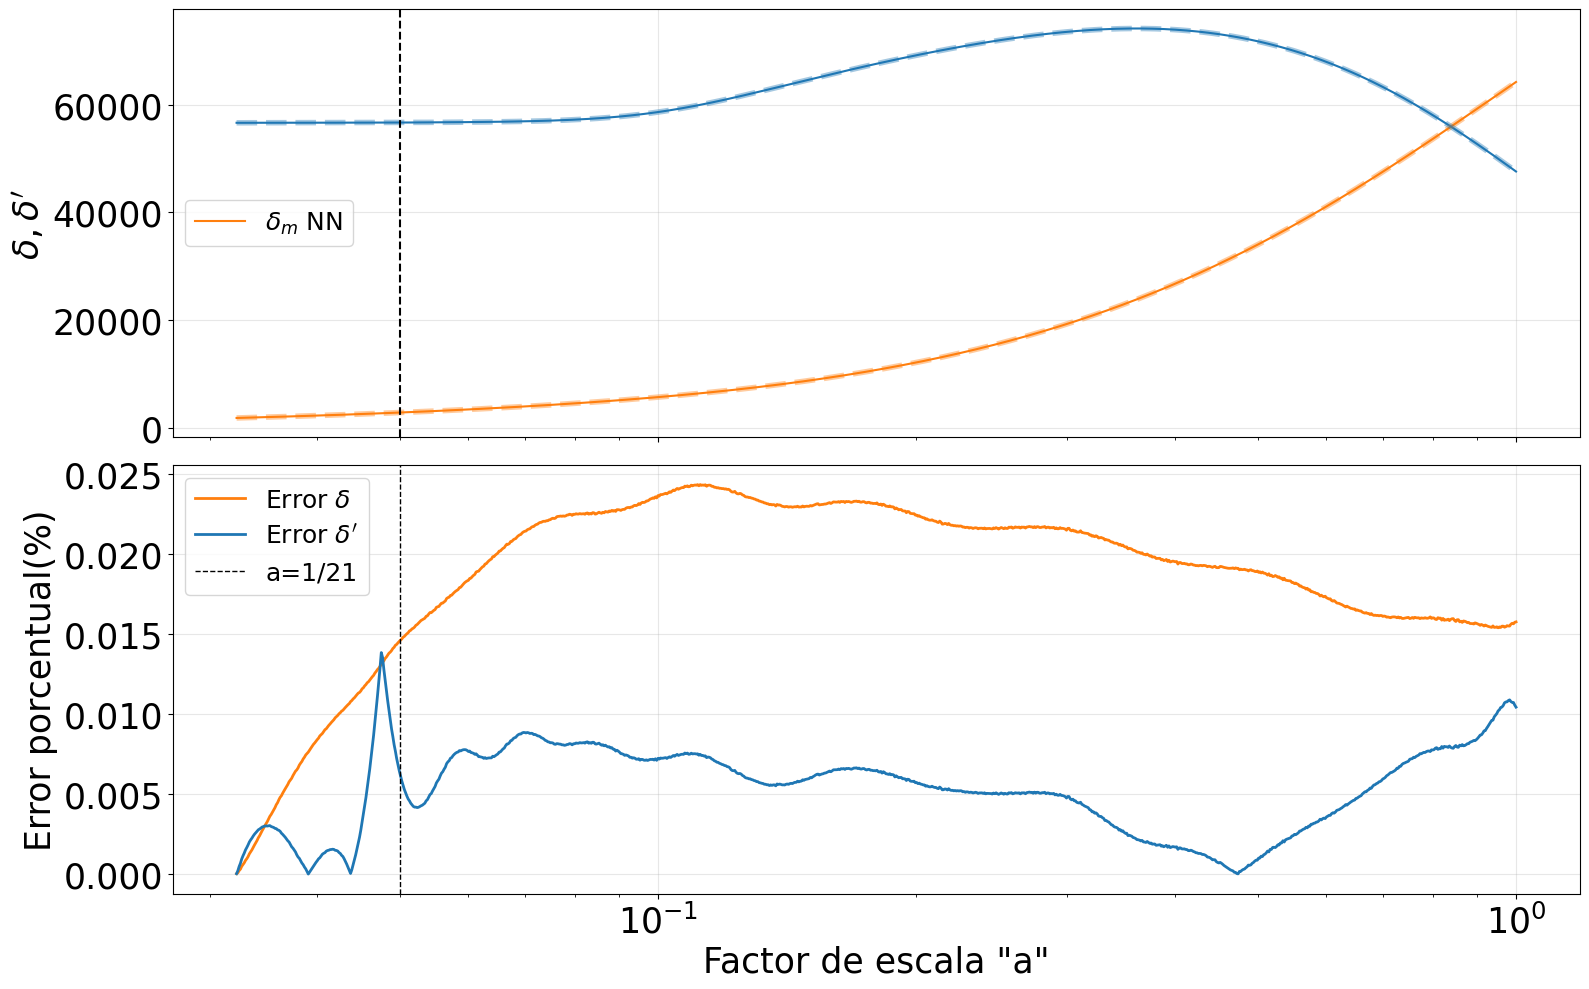

In [ ]:
device = torch.device('cpu') 

if 'r_prime' in globals():
    for net in r_prime.nets:
        net.to(device)
        net.float() 
if 'v' in globals():
    for net in v.nets:
        net.to(device)
        net.float()

# B) Redes del Solver (entrenadas) - Use loaded nets
target_nets = nets

for net in target_nets:
    net.to(device)
    net.float()
    net.eval()


def Geff_G_func_cpu_safe(z, k, b, Om_m_0, Lambda_val):
    z_in = np.asarray(z)
    
    # Manejo escalar vs array
    if z_in.ndim == 0:
        z_t = torch.tensor([z_in.item()], dtype=torch.float32, device=device)
        b_t = torch.tensor([float(b)], dtype=torch.float32, device=device)
        Om_t = torch.tensor([float(Om_m_0)], dtype=torch.float32, device=device)
    else:
        z_t = torch.as_tensor(z_in, dtype=torch.float32, device=device)
        b_t = torch.full_like(z_t, float(b), device=device)
        Om_t = torch.full_like(z_t, float(Om_m_0), device=device)

    z_prime_t = 1.0 - (z_t / z_rescale)
    b_prime_t = b_t / b_max

    # Inferencia (Todo en CPU)
    # Importante: to_numpy=False para mantener tensores
    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_t, to_numpy=False)
    
    # Cálculos
    r_prime_exp = torch.exp(r_prime_sol)
    Lambda_t = torch.tensor(float(Lambda_val), dtype=torch.float32, device=device)
    
    denomFR = 1.0 + (r_prime_exp * Lambda_t) / (Lambda_t * b_t)
    FR = 1.0 - 2.0 / (b_t * (denomFR ** 2))
    FRR = 4.0 / (Lambda_t * (b_t**2) * (denomFR ** 3))
    
    m = FRR / FR
    epsilon = (k**2) * ((1.0 + z_t)**2) * m
    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)
    
    return Geff_over_G.detach().numpy()

def ODE_MG_num_Hred(N_p, x_val, k_param, b, Om_m_0, Lambda):
    N = N_p * n_0
    a = np.exp(N)
    a_scalar = a.item() if np.ndim(a) == 0 else a
    z_scalar = (1.0 / a_scalar) - 1.0
    
    # Background
    H_z = np.interp(z_scalar, z_total, H_total)
    dHdz = np.interp(z_scalar, z_total, dH_dz_total)
    dHda = dHdz * (-1.0 / (a_scalar ** 2))
    
    # Geff Seguro
    mu_res = Geff_G_func_cpu_safe(z_scalar, k_param, b, Om_m_0, Lambda)
    mu_val = mu_res.item() if mu_res.size == 1 else mu_res[0]
    
    if z_scalar > z_0:
        mu_val = 1.0 

    term1 = n_0 * ((dHda / H_z) * a_scalar + 2)
    denom = (H_z ** 2) * (a_scalar ** 3)
    term2 = 1.5 * (Om_m_0 * (n_0 ** 2) * (H_0 ** 2)) * (mu_val / denom)
    
    return np.array([x_val[1], -x_val[1]**2 - term1 * x_val[1] + term2])

k_input_num = k_val*h
y0_num = [delta_inicial_net, delta_p_inicial_net] 
N_eval = np.linspace(N_p_0, N_p_f, 1000)

print("🧮 Ejecutando Scipy solve_ivp...")
sol_check = solve_ivp(
    fun=ODE_MG_num_Hred, 
    t_span=[N_p_0, N_p_f], 
    y0=y0_num, 
    t_eval=N_eval, 
    method='RK45', 
    args=(k_input_num, b, Om_m_0, Lambda),
    rtol=1e-10, atol=1e-12
)
print("✅ Numérico listo.")

# Datos Numéricos
a_num = np.exp(sol_check.t * n_0)
delta_num = np.exp(sol_check.y[0])
delta_p_num = delta_num * sol_check.y[1] / (n_0 * a_num)


condition = [IVP(N_p_0, delta_inicial_net), IVP(N_p_0, delta_p_inicial_net)]
sol_nn = Solution1D(target_nets, condition)

def eval_nn_safe(t_arr):
    t_t = torch.from_numpy(t_arr.astype(np.float32)).to(device)
    out = sol_nn(t_t, to_numpy=False) 
    return out[0].detach().numpy(), out[1].detach().numpy()

Np_vec = np.linspace(N_p_0, N_p_f, 1000)
print("🧠 Evaluando Red Neuronal...")
xN_nb, yN_nb = eval_nn_safe(Np_vec)

# Datos Red
a_vec  = np.exp(n_0 * Np_vec)
delta_nn_nb   = np.exp(xN_nb)  
delta_p_nn_nb = delta_nn_nb * yN_nb / (n_0 * a_vec)

# Error
delta_num_interp = np.interp(a_vec, a_num, delta_num)
delta_p_num_interp = np.interp(a_vec, a_num, delta_p_num)
diff_delta = 100 * np.abs((delta_nn_nb - delta_num_interp) / delta_num_interp)
diff_delta_p = 100 * np.abs((delta_p_nn_nb - delta_p_num_interp) / delta_p_num_interp)


fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'


ax1.plot(a_vec, delta_nn_nb, color=c_d, ls='-', lw=1.5, label=r'$\delta_m$ NN')
ax1.plot(a_vec, delta_p_nn_nb, color=c_p, ls='-', lw=1.5)#, label=r'$\delta^\prime_m$ NN')
ax1.plot(a_vec, delta_num,  color=c_d, ls='--', lw=4, alpha=0.4)#, label=r'$\delta_m$ Num (Clase)')
ax1.plot(a_vec, delta_p_num, color=c_p, ls='--', lw=4, alpha=0.4)#, label=r'$\delta^\prime_m$ Num (Clase)')
ax1.axvline(x=1/20, color='black', linestyle='--')#, label = 'a=1/21', linewidth=1)


ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax2.set_xlabel('a')
#ax1.set_ylabel(r'$\delta, \delta^\prime$', fontsize =18)
ax1.legend(loc='upper left')

ax2.plot(a_vec, diff_delta, color=c_d, ls='-', lw=2, label=r'Error $\delta$')
ax2.plot(a_vec, diff_delta_p, color=c_p, ls='-', lw=2, label=r'Error $\delta^\prime$')
ax2.set_xscale('log')
#ax2.set_xlabel(r"Factor de escala $a$", fontsize=18)
#ax2.set_ylabel("Diferencia porcentual [%]", fontsize=18)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)
ax1.set_ylabel(r'$\delta, \delta^\prime$', fontsize=25)
ax2.set_xlabel(r'Factor de escala "a"', fontsize = 25)
ax2.set_ylabel('Error porcentual(%)', fontsize=25)

ax1.tick_params(axis='y', labelsize=25) 
ax2.tick_params(axis='y', labelsize=25) 
ax2.grid(True, alpha=0.3)

# Leyenda para el gráfico inferior
# Example: Make the legend bigger
ax1.legend(loc='center left', fontsize=18)
ax2.legend(loc='upper left', fontsize=18)
ax2.tick_params(axis='x', labelsize=25) 

#ax2.set_ylim(0, 3.7)
plt.tight_layout()

plt.savefig(f'solución CI H red Om = {Om_m_0}, b={b}, k={k_val}.png')
plt.show()

## Comparación numérico puro

🧠 Evaluando Red Neuronal...


/tmp/ipykernel_12950/1517396044.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')
/tmp/ipykernel_12950/1517396044.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='center left', fontsize=25)


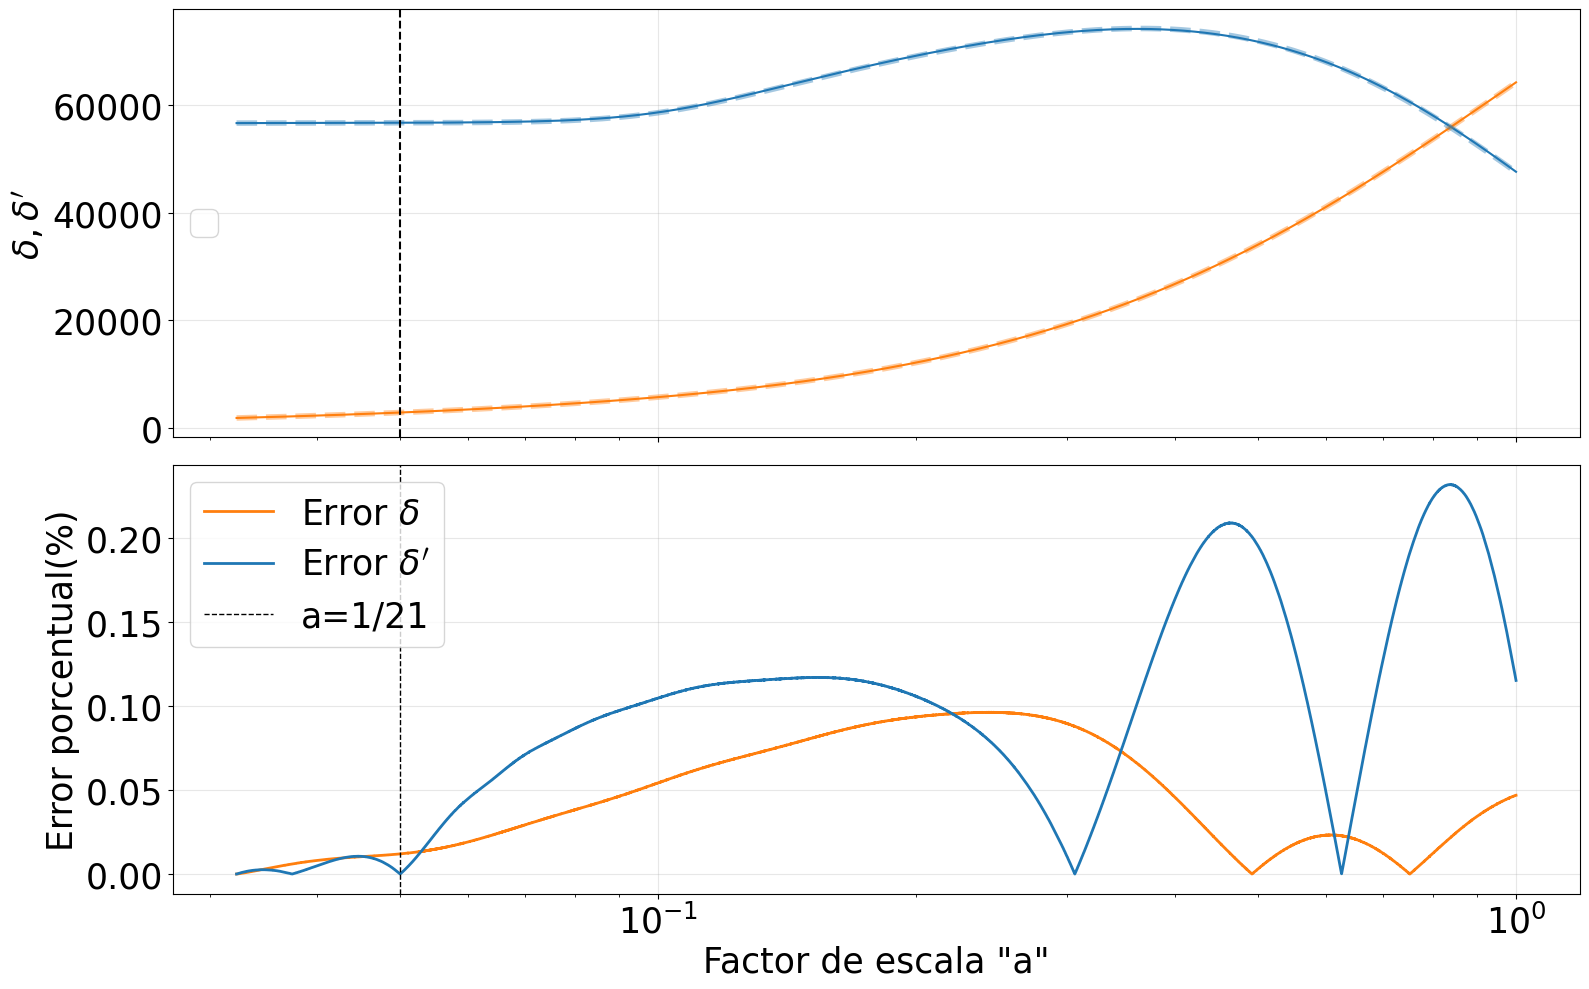

In [ ]:
# Vector de evaluación (dominio de la red)
Np_vec = np.linspace(N_p_0, N_p_f, 10000)

print("🧠 Evaluando Red Neuronal...")
xN_nb, yN_nb = eval_nn_safe(Np_vec)

# Reconstrucción física (x = ln(-delta))
a_vec = np.exp(n_0 * Np_vec) # Este será nuestro a_phys
delta_nn_nb = np.exp(xN_nb)
delta_p_nn_nb = delta_nn_nb * yN_nb / (n_0 * a_vec)


solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k_val)


H_num, H_prime_num, r_num = solver_clase.H_HS()

def delta_wrapper_manual(a, y):
    return solver_clase.delta_mg(a, y, H_num, H_prime_num, r_num)

y0_pedro = [delta_inicial, delta_p_inicial]

sol_MG_custom = solve_ivp(
    fun=delta_wrapper_manual, 
    t_span=[a_vec[0], a_vec[-1]], # Intervalo exacto de la red
    y0=y0_pedro, 
    t_eval=a_vec,   # Evaluar en los mismos a que la red
    method='RK45', 
    rtol=1e-10, 
    atol=1e-12
)

# 4.5. Extraer resultados
delta_num = np.abs(sol_MG_custom.y[0])
delta_p_num = np.abs(sol_MG_custom.y[1])

# Cálculo de diferencias
rel_diff_delta   = 100 * np.abs((delta_nn_nb - delta_num) / delta_num)
rel_diff_delta_p = 100 * np.abs((delta_p_nn_nb - delta_p_num) / delta_p_num)


fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'


ax1.plot(a_vec, delta_nn_nb, color=c_d, ls='-', lw=1.5) #, label=r'$\delta_m$ NN')
ax1.plot(a_vec, delta_p_nn_nb, color=c_p, ls='-', lw=1.5)#, label=r'$\delta^\prime_m$ NN')
ax1.plot(a_vec, delta_num,  color=c_d, ls='--', lw=4, alpha=0.4)#, label=r'$\delta_m$ Num (Clase)')
ax1.plot(a_vec, delta_p_num, color=c_p, ls='--', lw=4, alpha=0.4)#, label=r'$\delta^\prime_m$ Num (Clase)')
ax1.axvline(x=1/20, color='black', linestyle='--')#, label = 'a=1/21', linewidth=1)


ax1.set_xscale('log'); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('a'); ax1.set_ylabel(r'$\delta, \delta^\prime$', fontsize =18)
ax1.legend(loc='upper left')

ax2.plot(a_vec, rel_diff_delta, color=c_d, ls='-', lw=2, label=r'Error $\delta$')
ax2.plot(a_vec, rel_diff_delta_p, color=c_p, ls='-', lw=2, label=r'Error $\delta^\prime$')
ax2.set_xscale('log')
ax2.set_xlabel(r"Factor de escala $a$", fontsize=18)
ax2.set_ylabel("Diferencia porcentual [%]", fontsize=18)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)

ax1.set_ylabel(r'$\delta, \delta^\prime$', fontsize=25)
ax2.set_xlabel(r'Factor de escala "a"', fontsize = 25)
ax2.set_ylabel('Error porcentual(%)', fontsize=25)
ax2.tick_params(axis='x', labelsize=25) 

ax1.tick_params(axis='y', labelsize=25) 
ax2.tick_params(axis='y', labelsize=25) 
ax2.grid(True, alpha=0.3)

# Leyenda para el gráfico inferior
# Example: Make the legend bigger
ax1.legend(loc='center left', fontsize=25)
ax2.legend(loc='upper left', fontsize=25)
plt.tight_layout()

plt.savefig(f'solución CI H num Om = {Om_m_0}, b={b}, k={k_val}.png')

plt.show()